In [2]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

Defaulting to user installation because normal site-packages is not writeable


In [4]:
import os

print(os.getcwd())

C:\Users\ACER


In [1]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'intrusionproject.ipynb', 'KDDTest+.txt', 'KDDTrain+.txt']


In [2]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

In [4]:
columns = [
'duration','protocol_type','service','flag','src_bytes',
'dst_bytes','land','wrong_fragment','urgent','hot',
'num_failed_logins','logged_in','num_compromised',
'root_shell','su_attempted','num_root',
'num_file_creations','num_shells','num_access_files',
'num_outbound_cmds','is_host_login',
'is_guest_login','count','srv_count',
'serror_rate','srv_serror_rate','rerror_rate',
'srv_rerror_rate','same_srv_rate',
'diff_srv_rate','srv_diff_host_rate',
'dst_host_count','dst_host_srv_count',
'dst_host_same_srv_rate',
'dst_host_diff_srv_rate',
'dst_host_same_src_port_rate',
'dst_host_srv_diff_host_rate',
'dst_host_serror_rate',
'dst_host_srv_serror_rate',
'dst_host_rerror_rate',
'dst_host_srv_rerror_rate',
'label','difficulty'
]

In [33]:
train = pd.read_csv("KDDTrain+.txt", names=columns)
test = pd.read_csv("KDDTest+.txt", names=columns)

print(train.head())

   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2             

In [34]:
print("Training Dataset Shape:", train.shape)
print("Testing Dataset Shape:", test.shape)

Training Dataset Shape: (125973, 43)
Testing Dataset Shape: (22544, 43)


In [35]:
print(train.isnull().sum())

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [36]:
print(train['label'].value_counts())

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [37]:
train['label'] = train['label'].apply(lambda x: 0 if x == 'normal' else 1)
test['label'] = test['label'].apply(lambda x: 0 if x == 'normal' else 1)

In [38]:
train['label'].value_counts()

label
0    67343
1    58630
Name: count, dtype: int64

In [39]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = ['protocol_type', 'service', 'flag']

for col in categorical_columns:
    train[col] = encoder.fit_transform(train[col])
    test[col] = encoder.fit_transform(test[col])

In [40]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,1,20,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,0,20
1,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,0,15
2,0,1,49,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,1,19
3,0,1,24,9,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,0,21
4,0,1,24,9,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,21


In [41]:
X_train = train.drop(['label'], axis=1)
y_train = train['label']

X_test = test.drop(['label'], axis=1)
y_test = test['label']

In [42]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (125973, 42)
y_train: (125973,)
X_test : (22544, 42)
y_test : (22544,)


In [43]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [44]:
predictions = model.predict(X_test)

print(predictions[:20])

[1 1 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 1]


In [45]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8212384669978708


In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

print(cm)

[[9444  267]
 [3763 9070]]


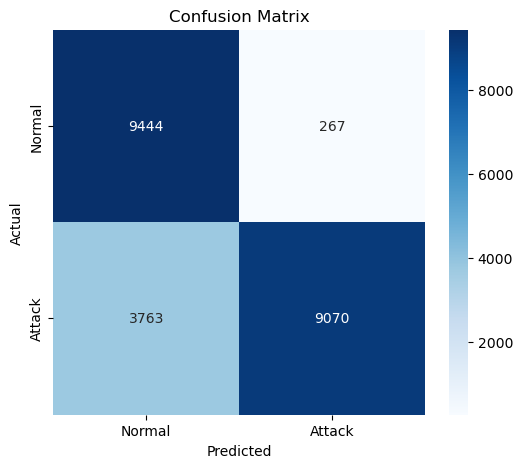

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal','Attack'],
    yticklabels=['Normal','Attack']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.72      0.97      0.82      9711
           1       0.97      0.71      0.82     12833

    accuracy                           0.82     22544
   macro avg       0.84      0.84      0.82     22544
weighted avg       0.86      0.82      0.82     22544



In [49]:
import joblib

joblib.dump(model, "ids_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [50]:
model = joblib.load("ids_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [51]:
sample = X_test.iloc[[10]]

prediction = model.predict(sample)

print("Prediction:", prediction)

Prediction: [0]


In [52]:
def self_healing(prediction):

    if prediction == 1:

        print("="*50)
        print("⚠ INTRUSION DETECTED")
        print("="*50)

        print("Step 1 : Blocking malicious IP")
        print("Step 2 : Updating firewall rules")
        print("Step 3 : Restarting affected network service")
        print("Step 4 : Logging the security event")
        print("Step 5 : Sending alert to administrator")

        print("\n✅ SELF-HEALING COMPLETED")

    else:

        print("="*50)
        print("Network Status : NORMAL")
        print("No healing required")
        print("="*50)

In [53]:
prediction = model.predict(sample)

self_healing(prediction[0])

Network Status : NORMAL
No healing required


In [54]:
for i in range(10):

    sample = X_test.iloc[[i]]

    prediction = model.predict(sample)

    print(f"\nSample {i}")

    self_healing(prediction[0])


Sample 0
⚠ INTRUSION DETECTED
Step 1 : Blocking malicious IP
Step 2 : Updating firewall rules
Step 3 : Restarting affected network service
Step 4 : Logging the security event
Step 5 : Sending alert to administrator

✅ SELF-HEALING COMPLETED

Sample 1
⚠ INTRUSION DETECTED
Step 1 : Blocking malicious IP
Step 2 : Updating firewall rules
Step 3 : Restarting affected network service
Step 4 : Logging the security event
Step 5 : Sending alert to administrator

✅ SELF-HEALING COMPLETED

Sample 2
Network Status : NORMAL
No healing required

Sample 3
⚠ INTRUSION DETECTED
Step 1 : Blocking malicious IP
Step 2 : Updating firewall rules
Step 3 : Restarting affected network service
Step 4 : Logging the security event
Step 5 : Sending alert to administrator

✅ SELF-HEALING COMPLETED

Sample 4
Network Status : NORMAL
No healing required

Sample 5
Network Status : NORMAL
No healing required

Sample 6
Network Status : NORMAL
No healing required

Sample 7
Network Status : NORMAL
No healing required

Sam

In [55]:
import pandas as pd

logs = []

for i in range(20):

    sample = X_test.iloc[[i]]

    pred = model.predict(sample)[0]

    status = "Attack" if pred == 1 else "Normal"

    if pred == 1:
        action = "Blocked IP | Restarted Service | Alert Sent"
    else:
        action = "No Action"

    logs.append({
        "Sample": i + 1,
        "Prediction": status,
        "Self-Healing Action": action
    })

log_df = pd.DataFrame(logs)

log_df

,Sample,Prediction,Self-Healing Action
0,1,Attack,Blocked IP | Restarted Service | Alert Sent
1,2,Attack,Blocked IP | Restarted Service | Alert Sent
2,3,Normal,No Action
3,4,Attack,Blocked IP | Restarted Service | Alert Sent
4,5,Normal,No Action
5,6,Normal,No Action
6,7,Normal,No Action
7,8,Normal,No Action
8,9,Normal,No Action
9,10,Attack,Blocked IP | Restarted Service | Alert Sent


In [56]:
log_df.to_csv("network_logs.csv", index=False)

print("Network log saved successfully!")

Network log saved successfully!
